In [1]:
# Open training, testing subsets from https://doi.org/10.1021/acs.energyfuels.0c01533
from csv import DictReader

with open('schweidtmann_train.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_train = [r for r in reader]
csv_file.close()
with open('schweidtmann_test.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_test = [r for r in reader]
csv_file.close()

print(len(compounds_train), len(compounds_test))

# Filter out compounds with `n.a.` RON or MON data
compounds_train = [c for c in compounds_train if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']
compounds_test = [c for c in compounds_test if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']

print(len(compounds_train), len(compounds_test))

430 75
265 51


In [2]:
# Format data for training
from ecnet.datasets.structs import QSPRDataset

smiles_train = [c[' SMILES'] for c in compounds_train]
ron_train = [float(c['Meas RON']) for c in compounds_train]
mon_train = [float(c['Meas MON']) for c in compounds_train]
targets_train = [[ron_train[i], mon_train[i]] for i in range(len(mon_train))]

smiles_test = [c[' SMILES'] for c in compounds_test]
ron_test = [float(c['Meas RON']) for c in compounds_test]
mon_test = [float(c['Meas MON']) for c in compounds_test]
targets_test = [[ron_test[i], mon_test[i]] for i in range(len(mon_test))]

dataset_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
dataset_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')

In [3]:
# Select most-influential descriptors w.r.t. RON and MON for NN input variables
from ecnet.tasks.feature_selection import select_rfr

print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
# Retain descriptors such that 99% of descriptor-property correlation is retained
desc_idx, desc_imp = select_rfr(dataset_train, total_importance=0.99, n_estimators=256, n_jobs=8)
dataset_train.set_desc_index(desc_idx)
dataset_test.set_desc_index(desc_idx)
print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
print(dataset_train.desc_names[:5], desc_imp[:5])

torch.Size([265, 5305]) torch.Size([51, 5305])
torch.Size([265, 856]) torch.Size([51, 856])
['SssCH2', 'ChiA_B(s)', 'GATS2m', 'Eta_L_A', 'SpMaxA_EA(bo)'] [0.21364152594852232, 0.16624372009616933, 0.1647549583216951, 0.027282791452216543, 0.021472518342552007]


Epoch: 0 | Train loss: 2961.695676407724 | Valid loss: 9223372036854775807
Epoch: 10 | Train loss: 202.0853271484375 | Valid loss: 152.0611114501953
Epoch: 20 | Train loss: 149.6677614607901 | Valid loss: 154.4530029296875
Epoch: 30 | Train loss: 107.96472923710661 | Valid loss: 146.6143341064453
Epoch: 40 | Train loss: 57.455387115478516 | Valid loss: 73.28195190429688
Epoch: 50 | Train loss: 77.9931103688366 | Valid loss: 65.12505340576172
Epoch: 60 | Train loss: 43.701540173224686 | Valid loss: 59.44524002075195
Epoch: 70 | Train loss: 57.49942376478663 | Valid loss: 70.12091064453125
Epoch: 80 | Train loss: 45.20842886870762 | Valid loss: 64.89633178710938
Epoch: 90 | Train loss: 43.50453718653265 | Valid loss: 57.97608947753906
Epoch: 100 | Train loss: 35.12890344295862 | Valid loss: 40.34911346435547
Epoch: 110 | Train loss: 25.45473401051647 | Valid loss: 34.84647750854492
Epoch: 120 | Train loss: 36.07661106901349 | Valid loss: 33.016319274902344
Epoch: 130 | Train loss: 18.966

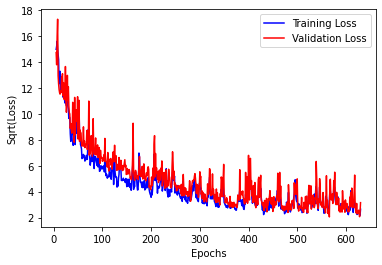

In [4]:
# Create ECNet model
from ecnet import ECNet
from math import sqrt
from matplotlib import pyplot as plt

model = ECNet(dataset_train.desc_vals.shape[1], dataset_train.target_vals.shape[1], 1024, 1, 0.005)
train_loss, valid_loss = model.fit(
    dataset=dataset_train, valid_size=0.2, shuffle=True, verbose=10,
    patience=64, epochs=1000, lr=0.001, lr_decay=1e-10
)

# Plot sqrt(MSE loss)
train_loss = [sqrt(l) for l in train_loss][5:]
valid_loss = [sqrt(l) for l in valid_loss][5:]
epoch = [i for i in range(5, len(train_loss) + 5)]
plt.clf()
plt.xlabel('Epochs')
plt.ylabel('Sqrt(Loss)')
plt.plot(epoch, train_loss, color='blue', label='Training Loss')
plt.plot(epoch, valid_loss, color='red', label='Validation Loss')
plt.legend(loc='upper right')
plt.show()

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score

y_hat_train = model(dataset_train.desc_vals).detach().numpy()
y_train = dataset_train.target_vals.numpy()
y_hat_test = model(dataset_test.desc_vals).detach().numpy()
y_test = dataset_test.target_vals.numpy()

y_hat_train_ron = [y[0] for y in y_hat_train]
y_hat_train_mon = [y[1] for y in y_hat_train]
y_train_ron = [y[0] for y in y_train]
y_train_mon = [y[1] for y in y_train]

y_hat_test_ron = [y[0] for y in y_hat_test]
y_hat_test_mon = [y[1] for y in y_hat_test]
y_test_ron = [y[0] for y in y_test]
y_test_mon = [y[1] for y in y_test]

mae_ron_train = mean_absolute_error(y_hat_train_ron, y_train_ron)
mae_ron_test = mean_absolute_error(y_hat_test_ron, y_test_ron)
mae_mon_train = mean_absolute_error(y_hat_train_mon, y_train_mon)
mae_mon_test = mean_absolute_error(y_hat_test_mon, y_test_mon)
r2_ron_train = r2_score(y_hat_train_ron, y_train_ron)
r2_ron_test = r2_score(y_hat_test_ron, y_test_ron)
r2_mon_train = r2_score(y_hat_train_mon, y_train_mon)
r2_mon_test = r2_score(y_hat_test_mon, y_test_mon)

print(f'RON Train: {mae_ron_train} | {r2_ron_train}')
print(f'RON Test: {mae_ron_test} | {r2_ron_test}')
print(f'MON Train: {mae_mon_train} | {r2_mon_train}')
print(f'MON Test: {mae_mon_test} | {r2_mon_test}')

RON Train: 2.792091131210327 | 0.9821125525954522
RON Test: 4.831325054168701 | 0.9334786115039184
MON Train: 2.4293038845062256 | 0.9794671957146074
MON Test: 5.513441562652588 | 0.8765697541217691


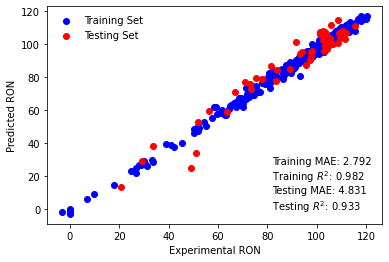

In [6]:
from matplotlib.offsetbox import AnchoredText

plt.clf()
plt.xlabel('Experimental RON')
plt.ylabel('Predicted RON')
plt.scatter(y_train_ron, y_hat_train_ron, color='blue', label='Training Set')
plt.scatter(y_test_ron, y_hat_test_ron, color='red', label='Testing Set')
plt.legend(loc='upper left', edgecolor='w')
string = 'Training MAE: {:.3f}'.format(mae_ron_train) + '\n'
string += 'Training $R^2$: {:.3f}'.format(r2_ron_train) + '\n'
string += 'Testing MAE: {:.3f}'.format(mae_ron_test) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(r2_ron_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.show()

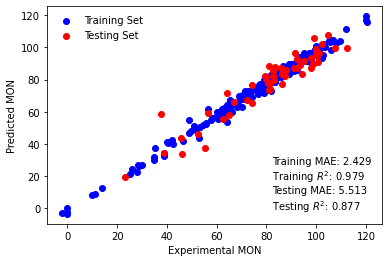

In [7]:
plt.clf()
plt.xlabel('Experimental MON')
plt.ylabel('Predicted MON')
plt.scatter(y_train_mon, y_hat_train_mon, color='blue', label='Training Set')
plt.scatter(y_test_mon, y_hat_test_mon, color='red', label='Testing Set')
plt.legend(loc='upper left', edgecolor='w')
string = 'Training MAE: {:.3f}'.format(mae_mon_train) + '\n'
string += 'Training $R^2$: {:.3f}'.format(r2_mon_train) + '\n'
string += 'Testing MAE: {:.3f}'.format(mae_mon_test) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(r2_mon_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.show()